In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC



In [4]:
df = pd.read_csv("predictive_performance_data.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
df["Machine failure"].value_counts()

0    9661
1     339
Name: Machine failure, dtype: int64

In [8]:
# Drop ID columns (no predictive value)
df = df.drop(columns=["UDI", "Product ID"])

# One-hot encode machine type
df = pd.get_dummies(df, columns=["Type"], drop_first=True)
df.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,0


In [13]:
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (10000, 12)
Target shape: (10000,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42,stratify=y)


In [15]:
#Scaling ensures all sensor readings contribute equally to the model.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(probability=True, class_weight="balanced", random_state=42)
}


In [17]:
results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall
    })
    
    print(f"\n{model_name}")
    print("Accuracy:", accuracy)
    print("Recall:", recall)



Logistic Regression
Accuracy: 0.999
Recall: 0.9705882352941176

Decision Tree
Accuracy: 0.999
Recall: 0.9705882352941176

Random Forest
Accuracy: 0.9985
Recall: 0.9558823529411765

Support Vector Machine
Accuracy: 0.999
Recall: 0.9705882352941176


In [18]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall", ascending=False)


,Model,Accuracy,Recall
0,Logistic Regression,0.9990,0.970588
1,Decision Tree,0.9990,0.970588
3,Support Vector Machine,0.9990,0.970588
2,Random Forest,0.9985,0.955882


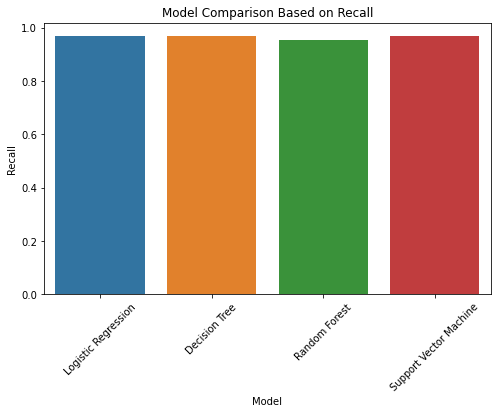

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Recall", data=results_df)
plt.title("Model Comparison Based on Recall")
plt.xticks(rotation=45)
plt.show()


In [27]:
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

best_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [28]:
y_pred = best_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.999
Recall: 0.9705882352941176

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



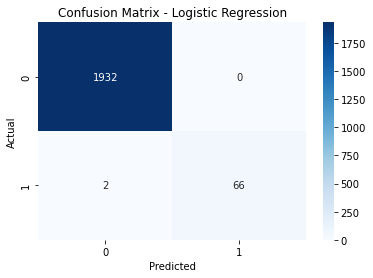

In [26]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


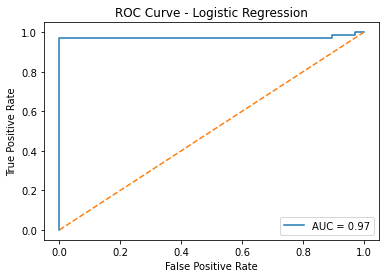

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
#ROC-AUC shows how well the model separates failure and non-failure cases.

In [31]:
importance = pd.Series(
    best_model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

importance.head(10)


PWF                        1.456324
OSF                        1.334180
HDF                        1.247980
TWF                        0.933551
Air temperature [K]        0.842612
Type_L                    -0.534671
Process temperature [K]   -0.338504
Rotational speed [rpm]    -0.254358
Torque [Nm]                0.140971
Tool wear [min]           -0.130499
dtype: float64

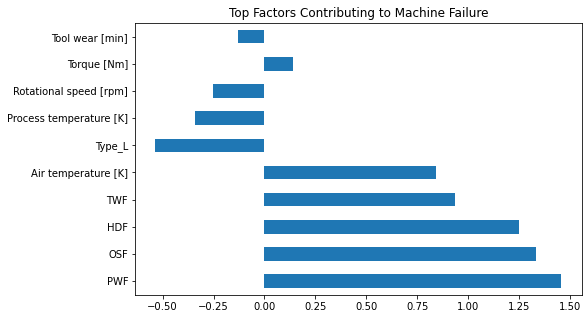

In [32]:
importance.head(10).plot(kind="barh", figsize=(8,5))
plt.title("Top Factors Contributing to Machine Failure")
plt.show()


In [33]:
df_full = pd.read_csv("predictive_performance_data.csv")

machine_ids = df_full["UDI"]

df_full = df_full.drop(columns=["UDI", "Product ID"])
df_full = pd.get_dummies(df_full, columns=["Type"], drop_first=True)

df_full["Failure_Probability"] = best_model.predict_proba(
    scaler.transform(df_full.drop(columns=["Machine failure"]))
)[:,1]

df_full.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M,Failure_Probability
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,1,0.029631
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,0,0.010565
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,0,0.009727
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,0,0.009417
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,0,0.009560


In [44]:
high_risk_machines = df_full[df_full["Failure_Probability"] > 0.7]
print("Number of high-risk machines:", len(high_risk_machines))
top_risky = df_full.sort_values(
    by="Failure_Probability",
    ascending=False
).head(330)

top_risky[["Failure_Probability"]]


Number of high-risk machines: 330


,Failure_Probability
5909,1.000000
5394,1.000000
4342,1.000000
1324,1.000000
5401,1.000000
...,...
9758,0.999289
50,0.999259
1391,0.999247
463,0.998762
